**ML COURSE 2025-2026**
# Esame - 1° Appello - 17/06/2025

**ISTRUZIONI**

- Scarica/visualizza le slide della teoria e il cheatsheet qua https://cloud.dei.unipd.it/index.php/s/NgGCT2pj5jddgJd

- Completa **tutte le sezioni** dove trovi scritto <span style="color:red"><strong>TODO</strong></span> e <span style="color:red"><strong>Risposta</strong></span>

  
  - In alcuni casi, <span style="color:red"><strong>Risposta</strong></span> sarà all'interno di una **cella di testo**: in quel caso, dovrai rispondere **a parole** alla domanda posta.  
  
  - In altri casi, sarà all'interno di una **cella di codice**: in quel caso, dovrai completare la cella **implementando quanto richiesto**.



- **Aggiungi commenti al codice** per spiegare chiaramente cosa stai facendo. Questo passaggio è molto importante: in alcuni casi è **più importante del codice stesso**.

- Assicurati che, cliccando su **"Restart and Run All"**, il codice funzioni **senza errori**, per quanto possibile.

- **Motiva le scelte più critiche**.



**Quando hai finito**:

1. Scarica il notebook.  
2. Caricalo su **Moodle Esami**.



 *(In seguito troverai uno screenshot che mostra come scaricare il notebook da Jupyter.)*

![Screenshot: come scaricare il notebook da Jupyter](istruzioni.png)


In [1]:
# AGGIUNGI I TUOI DATI
n_matricola = 00000
nome = "..."
cognome = "..."

In [2]:
# NOTE: Suggerimenti utili per implementare il codice
# ----------------------------------------------------------

# OPERAZIONI CON ARRAY E DATAFRAME
# df_ridotto = data[['colonna1', 'colonna2']]
# array = df_ridotto.to_numpy()
# array con la media di ogni colonna: np.mean(array, axis=0) 
# array con la media di ogni riga: np.mean(array, axis=1)
# array con la media di tutti gli elementi: np.mean(array)
# (lo stesso per np.sum, np.std, np.var, np.min, np.max)

# AGGIUNGERE ARRAY COLONNA  E ARRAY RIGA A UNA MATRICE E CONCATENARE MATRICI
# aggiungi un array colonna a sinistra della matrice np.hstack((array_colonna, matrice))
# aggiungi un array colonna a destra della matrice np.hstack((matrice, array_colonna))
# aggiungi un array riga in alto alla matrice np.vstack((array_riga, matrice))
# aggiungi un array riga in basso alla matrice np.vstack((matrice, array_riga))
# aggiungi una matrice a sinistra della matrice np.hstack((matrice1, matrice2))

# DISTANZA EUCLIDEA TRA DUE VETTORI 
# np.linalg.norm(array1 - array2)

## 1. Preprocessing and Data Analysis

**Caratteristiche del dataset**
- dataset reale: _Becker, B. & Kohavi, R. (1996). Adult [Dataset]. UCI Machine Learning Repository._
- target: `income-over-50k`, ovvero se il reddito annuale del soggetto è superiore a 50.000 dollari.

Qui presentiamo una versione aggiustata di Adult. Gli attributi (features) riguardano il capitale di ciascun individuo, i propri titoli accademici, il proprio lavoro, lo stato maritale, oltre ad alcuni dati personali tra cui il sesso, lo stato socio-economico, l'età, la dimensione dell'occhio, il colore preferito...

### 1.1 Exploration and Data Visualization

Proponiamo una visualizzazione e analisi esplorativa dei dati per comprendere le caratteristiche del dataset e le relazioni tra le variabili.

Potete modificare le celle di codice per stampare e visualizzare ulteriormente i dati.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns

In [4]:
df = pd.read_csv("adult_dataset.csv.gz")

In [5]:
# Mostra le prime 5 righe del DataFrame
df.head()

,age,capital-gain,capital-loss,education,eye-diameter,favourite-color,hours-per-week,marital-status,native-country,occupation,quantum-decoherence,race,relationship,sex,workclass,income-over-50k
0,39,2174,0,Bachelors,38.820262,blue,40,Never-married,United-States,Adm-clerical,NaN,White,Not-in-family,Male,State-gov,False
1,50,0,0,Bachelors,32.000786,green,13,Married-civ-spouse,United-States,Exec-managerial,0.480367,White,Husband,Male,Self-emp-not-inc,False
2,38,0,0,HS-grad,34.893690,blue,40,Divorced,United-States,Handlers-cleaners,NaN,White,Not-in-family,Male,Private,False
3,53,0,0,11th,41.204466,blue,40,Married-civ-spouse,United-States,Handlers-cleaners,0.563723,Black,Husband,Male,Private,False
4,28,0,0,Bachelors,39.337790,blue,40,Married-civ-spouse,Cuba,Prof-specialty,NaN,Black,Wife,Female,Private,False


In [ ]:
# Separa le feature e il target
target_col = "income-over-50k"
X = df.drop(columns=[target_col])
y = df[target_col]

<span style="color:red"><strong>TODO 1</strong></span>: Sapendo che questo è un task di classificazione (binaria): 
quale aspetto del dataset potrebbe influenzare il modo in cui si divide in train / test split
e la scelta della metrica di valutazione?

Utilizza la visualizzazione che segue per rispondere alla domanda.

<Axes: xlabel='income-over-50k'>

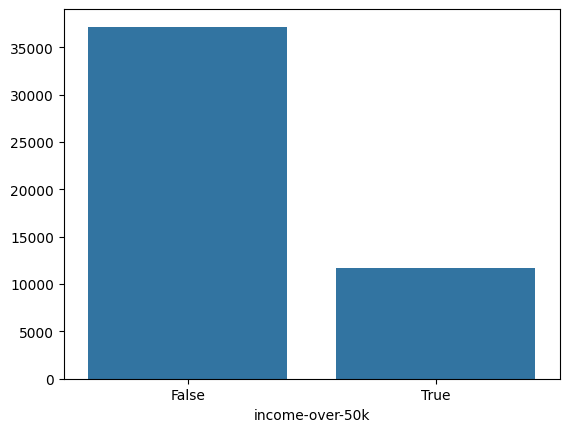

In [7]:
sns.barplot(x=y.value_counts().index, y=y.value_counts().values)

<span style="color:red"><strong>Risposta</strong></span>:
```
...
```

<span style="color:red"><strong>TODO 2</strong></span>: Utilizza l'esplorazione dei dati che segue per trarre conclusioni sulle colonne del dataset. Cosa ci dicono i valori unici di ciascuna colonna?

In [8]:
# dimensione del dataset
print("Dimension of the dataset:")
display(pd.Series([X.shape[0], X.shape[1]], index=['rows', 'features']))

Dimension of the dataset:


rows        48842
features       15
dtype: int64

In [9]:
# controllare il data type delle colonne può aiutare a capire quali feature potrebbero essere categoriche o numeriche
print("\nData types of each feature:")
X.dtypes


Data types of each feature:


age                      int64
capital-gain             int64
capital-loss             int64
education               object
eye-diameter           float64
favourite-color         object
hours-per-week           int64
marital-status          object
native-country          object
occupation              object
quantum-decoherence    float64
race                    object
relationship            object
sex                     object
workclass               object
dtype: object

In [10]:
print("\nNumber of unique values in each feature:")
display(X.nunique())


Number of unique values in each feature:


age                       74
capital-gain             123
capital-loss              99
education                 16
eye-diameter           48842
favourite-color            4
hours-per-week            96
marital-status             7
native-country            42
occupation                15
quantum-decoherence     5005
race                       5
relationship               6
sex                        2
workclass                  9
dtype: int64

In [11]:
is_categorical = {k: v <= 42 for k, v in X.nunique().to_dict().items()}
numerical_features = [k for k, v in is_categorical.items() if not v]
categorical_features = [k for k, v in is_categorical.items() if v]

<span style="color:red"><strong>Risposta</strong></span>:
```
...
```

<span style="color:red"><strong>TODO 3</strong></span>: Cosa possiamo dire riguardo ai valori mancanti? (Utilizza i dati che seguono per rispondere alla domanda)

In [12]:
# controlla se ci sono valori mancanti nel dataset
print("\nMissing values in each feature:")
print(X.isnull().sum())


Missing values in each feature:
age                        0
capital-gain               0
capital-loss               0
education                  0
eye-diameter               0
favourite-color            0
hours-per-week             0
marital-status             0
native-country           274
occupation               966
quantum-decoherence    43837
race                       0
relationship               0
sex                        0
workclass                963
dtype: int64


<span style="color:red"><strong>Risposta</strong></span>:
```
...
```

<span style="color:red"><strong>TODO 4</strong></span>: cosa studiamo di seguito? Che conclusione possiamo trarre?

,age,capital-gain,capital-loss,eye-diameter,hours-per-week,quantum-decoherence,income-over-50k
age,1.000000,0.077229,0.056944,-0.000037,0.071558,0.049085,0.230369
capital-gain,0.077229,1.000000,-0.031441,-0.002500,0.082157,0.023137,0.223013
capital-loss,0.056944,-0.031441,1.000000,-0.008142,0.054467,0.039001,0.147554
eye-diameter,-0.000037,-0.002500,-0.008142,1.000000,0.003698,0.001165,-0.006293
hours-per-week,0.071558,0.082157,0.054467,0.003698,1.000000,0.025469,0.227687
quantum-decoherence,0.049085,0.023137,0.039001,0.001165,0.025469,1.000000,0.130315
income-over-50k,0.230369,0.223013,0.147554,-0.006293,0.227687,0.130315,1.000000


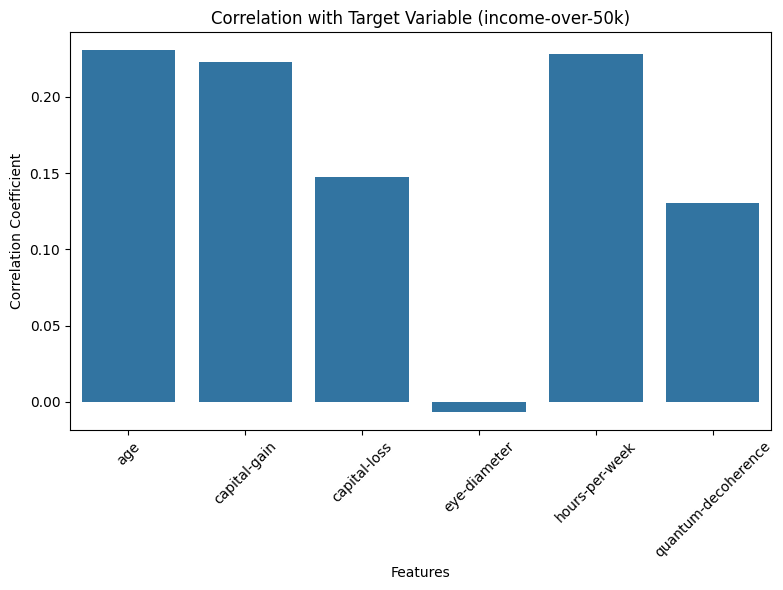

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = df.copy()
corr_matrix = df_corr[numerical_features + [target_col]].corr()
display(corr_matrix)
target_corr = corr_matrix[target_col].drop(target_col)

plt.figure(figsize=(8, 6))
sns.barplot(x=target_corr.index, y=target_corr.values, color=f"C0")
plt.title(f"Correlation with Target Variable ({target_col})")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

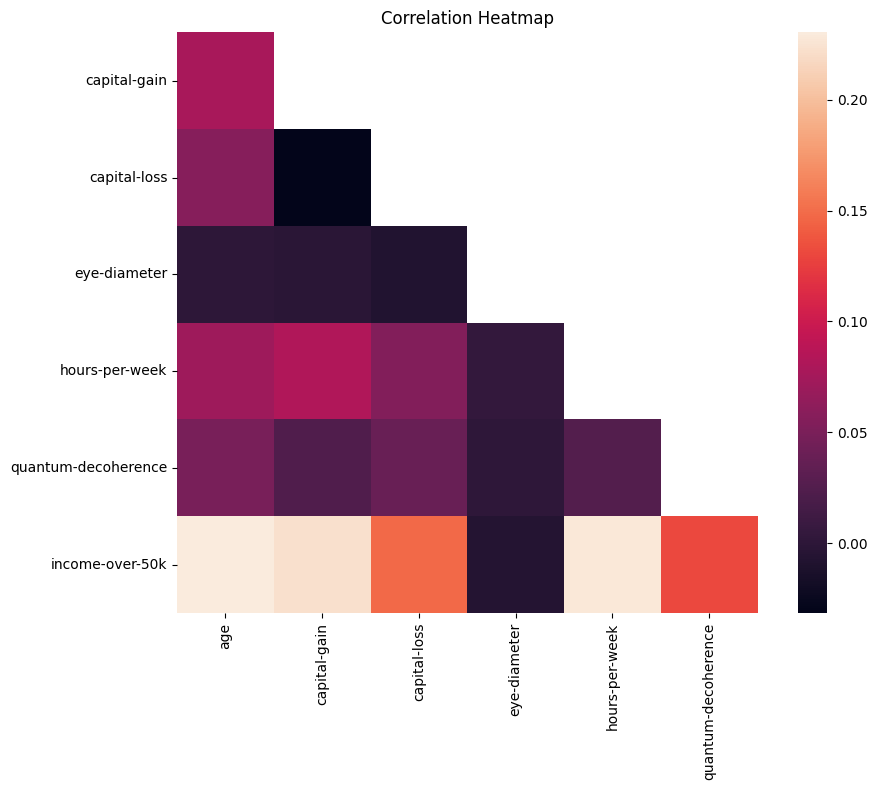

In [14]:
c = corr_matrix[corr_matrix.columns[:-1]].iloc[1:]
mask = np.triu(np.ones_like(c, dtype=bool), k=1)

plt.figure(figsize=(10, 8))
sns.heatmap(c, mask=mask, cbar=True, square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

<span style="color:red"><strong>Risposta</strong></span>:
```
...
```

<span style="color:red"><strong>TODO 5</strong></span>: che conclusioni possiamo trarre dalle seguenti visualizzazioni?

In [15]:
# esaminiamo la variabile target
print("\nTarget variable (income) unique values:", len(y.unique()))
print("Target variable (income) unique values:", y.unique())


Target variable (income) unique values: 2
Target variable (income) unique values: [False  True]


In [16]:
# possiamo usare .describe() per avere un riassunto delle feature numeriche
print("\nSummary statistics of numerical features:")
X.describe()


Summary statistics of numerical features:


,age,capital-gain,capital-loss,eye-diameter,hours-per-week,quantum-decoherence
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000,5005.000000
mean,38.643585,1079.067626,87.502314,29.984623,40.422382,0.523608
std,13.710510,7452.019058,403.004552,4.982516,12.391444,0.305581
min,17.000000,0.000000,0.000000,6.700235,1.000000,0.000207
25%,28.000000,0.000000,0.000000,26.643203,40.000000,0.260966
50%,37.000000,0.000000,0.000000,29.999553,40.000000,0.520213
75%,48.000000,0.000000,0.000000,33.344858,45.000000,0.780780
max,90.000000,99999.000000,4356.000000,49.158951,99.000000,1.199900


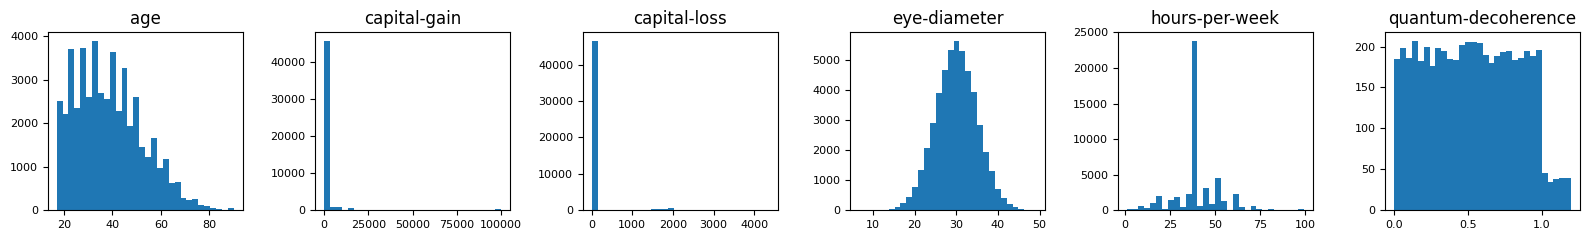

In [17]:
# visualizziamo la distribuzione delle feature 
import matplotlib.pyplot as plt

# plottiamo la distribuzione di tutte le feature numeriche come subplot
fig, axes = plt.subplots(nrows=1, ncols=len(numerical_features), figsize=(16, 2.5))
axes = axes.flatten()
for i, feature in enumerate(numerical_features):
    axes[i].hist(X[feature].dropna(), bins=30)
    axes[i].set_title(feature)
    axes[i].tick_params(axis="both", which="major", labelsize=8)
plt.tight_layout()
plt.show()

Text(0.5, 1.02, 'Pairplot of Numerical Features')

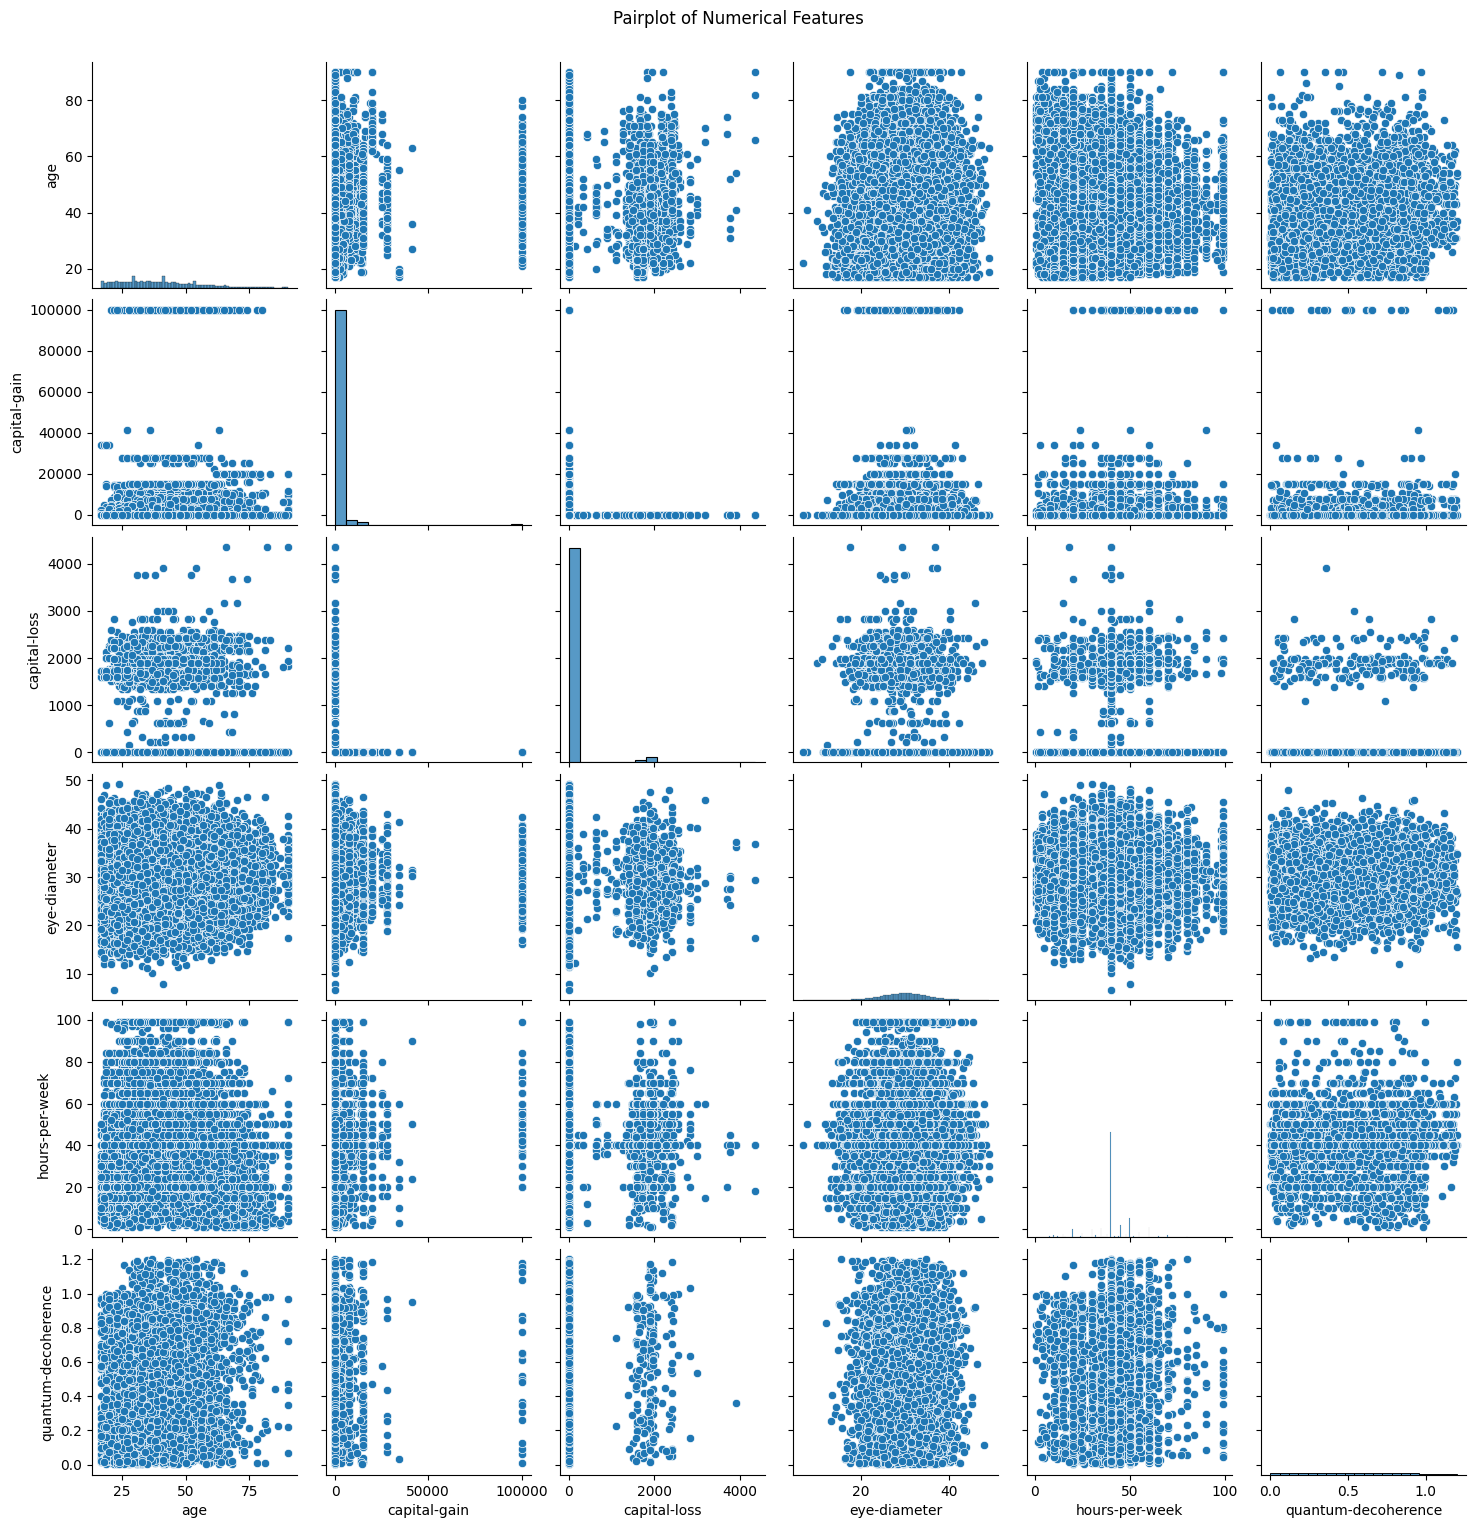

In [18]:
# Pairplot delle feature numeriche
sns.pairplot(X[numerical_features])
plt.suptitle("Pairplot of Numerical Features", y=1.02)

<span style="color:red"><strong>Risposta</strong></span>:
```
...
```

<span style="color:red"><strong>TODO 6</strong></span>: dal punto di vista delle variabili categoriche, cosa ci dice la seguente visualizzazione?

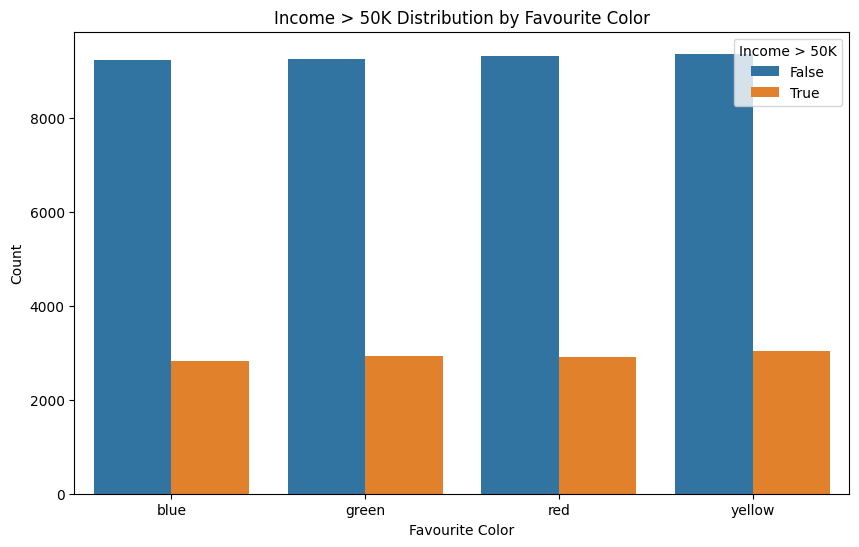

In [19]:
# visualizziamo la distribuzione della variabile target rispetto alla feature "favourite-color" 
# per vedere se c'è qualche pattern 
plt.figure(figsize=(10, 6))
sns.countplot(
    x="favourite-color",
    hue=target_col,
    data=df,
)
plt.title("Income > 50K Distribution by Favourite Color")
plt.xlabel("Favourite Color")
plt.ylabel("Count")
plt.legend(title="Income > 50K", labels=["False", "True"])

<span style="color:red"><strong>Risposta</strong></span>:
```
...
```

### 1.2 Visualization

In questa sezione, proponiamo altre visualizzazioni per comprendere meglio ulteriori aspetti del dataset.

<span style="color:red"><strong>TODO 7</strong></span>: dal punto di vista della distribuzione delle classi nelle feature, cosa ci dice la seguente visualizzazione?

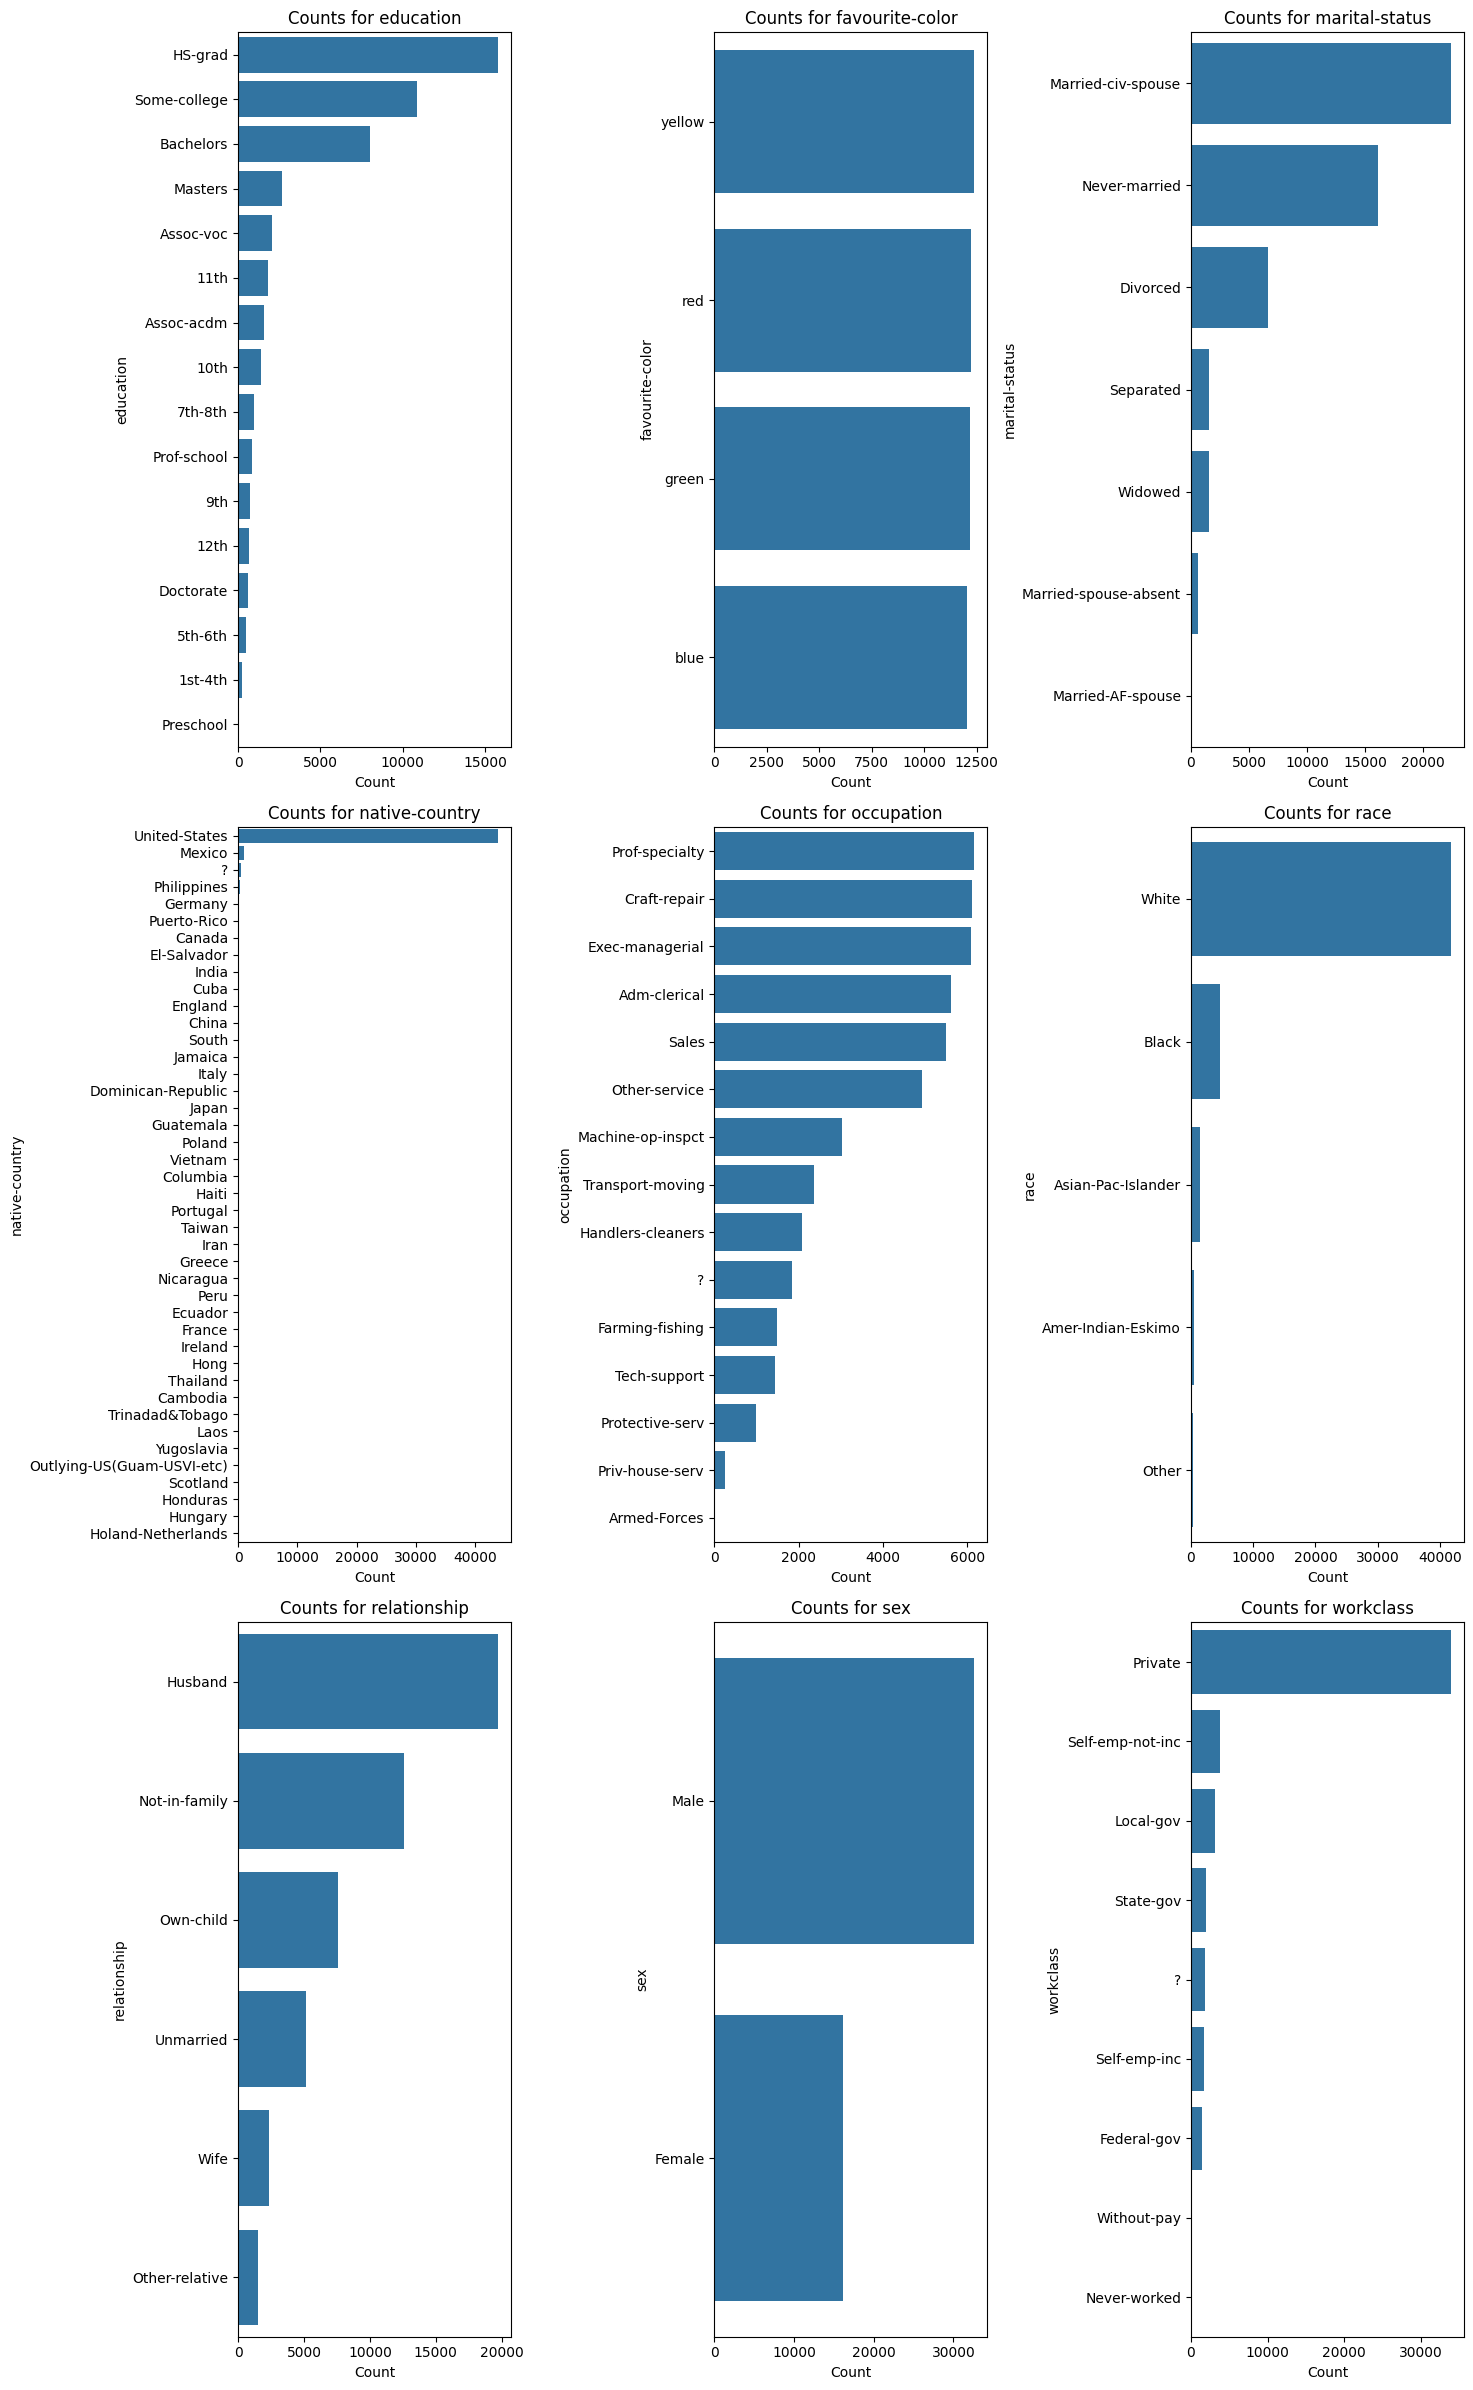

In [20]:
n_cat = len(categorical_features)
n_rows = (n_cat + 3 - 1) // 3  
fig, axes = plt.subplots(n_rows, 3, figsize=(15, 8 * n_rows), sharey=False, )
axes = axes.flatten()
for i, feature in enumerate(categorical_features):
    sns.countplot(
        data=df, y=feature, ax=axes[i], order=df[feature].value_counts().index
    )
    axes[i].set_title(f"Counts for {feature}")
    axes[i].set_ylabel(feature)
    axes[i].set_xlabel("Count")
plt.tight_layout()
plt.show()

C:\Users\zacca\AppData\Local\Temp\ipykernel_16164\3537164553.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['False', 'True'])
C:\Users\zacca\AppData\Local\Temp\ipykernel_16164\3537164553.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['False', 'True'])
C:\Users\zacca\AppData\Local\Temp\ipykernel_16164\3537164553.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['False', 'True'])
C:\Users\zacca\AppData\Local\Temp\ipykernel_16164\3537164553.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['False', 'True'])
C:\Users\zacca\AppData\Local\Temp\ip

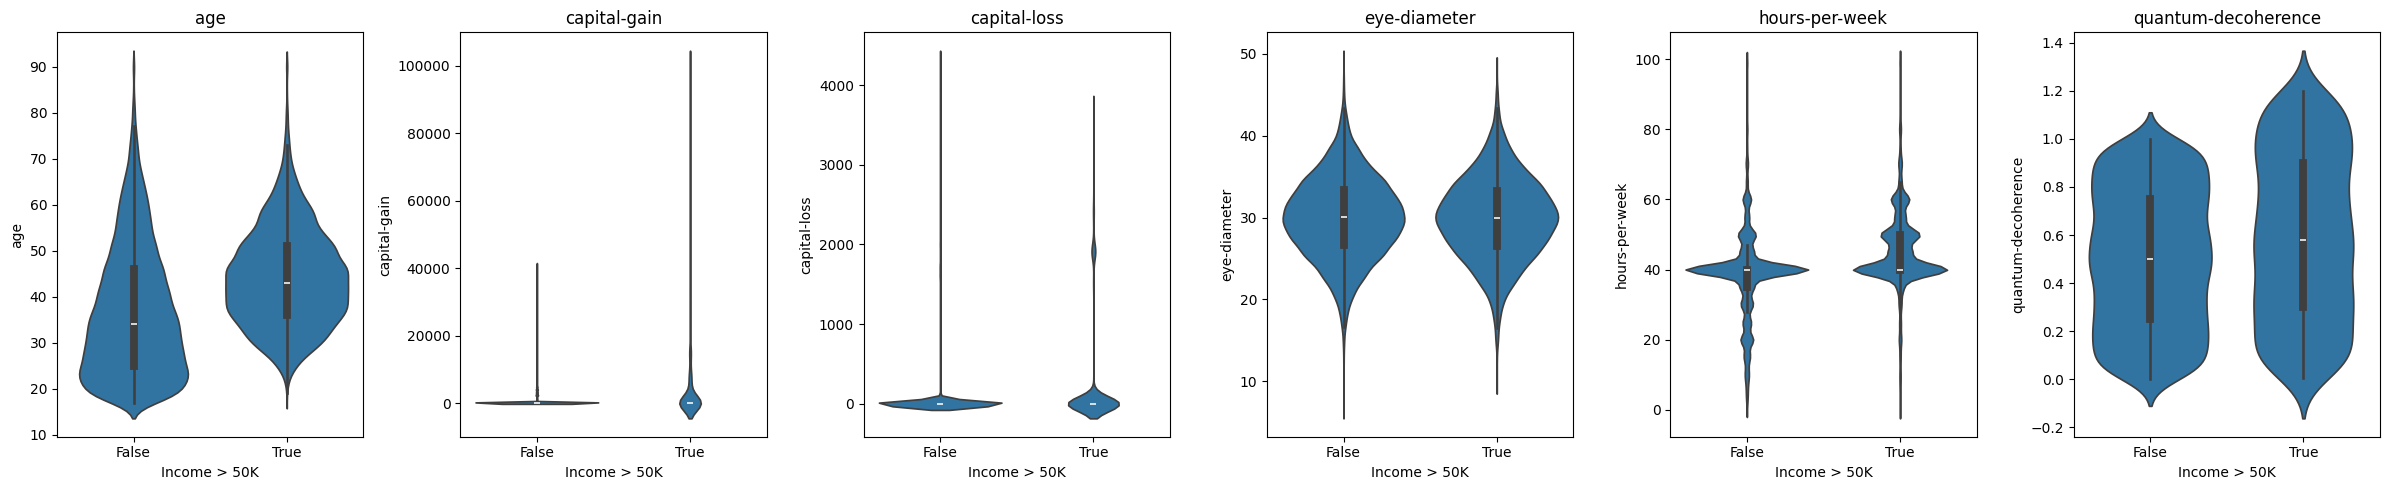

In [21]:
# Violinplot per ogni feature numerica, diviso per ogni valore del target
fig, axes = plt.subplots(1, len(numerical_features), figsize=(4 * len(numerical_features), 5))
for i, feature in enumerate(numerical_features):
    sns.violinplot(
        x=target_col,
        y=feature,
        data=df,
        ax=axes[i],
        split=False
    )
    axes[i].set_title(feature)
    axes[i].set_xlabel('Income > 50K')
    axes[i].set_xticklabels(['False', 'True'])
plt.tight_layout()
plt.show()

<span style="color:red"><strong>Risposta</strong></span>:
```
...
```

<span style="color:red"><strong>TODO 8</strong></span>: di seguito vediamo la distribuzione delle variabili numeriche per ogni classe di ogni variabile categorica. Cosa ci dice?

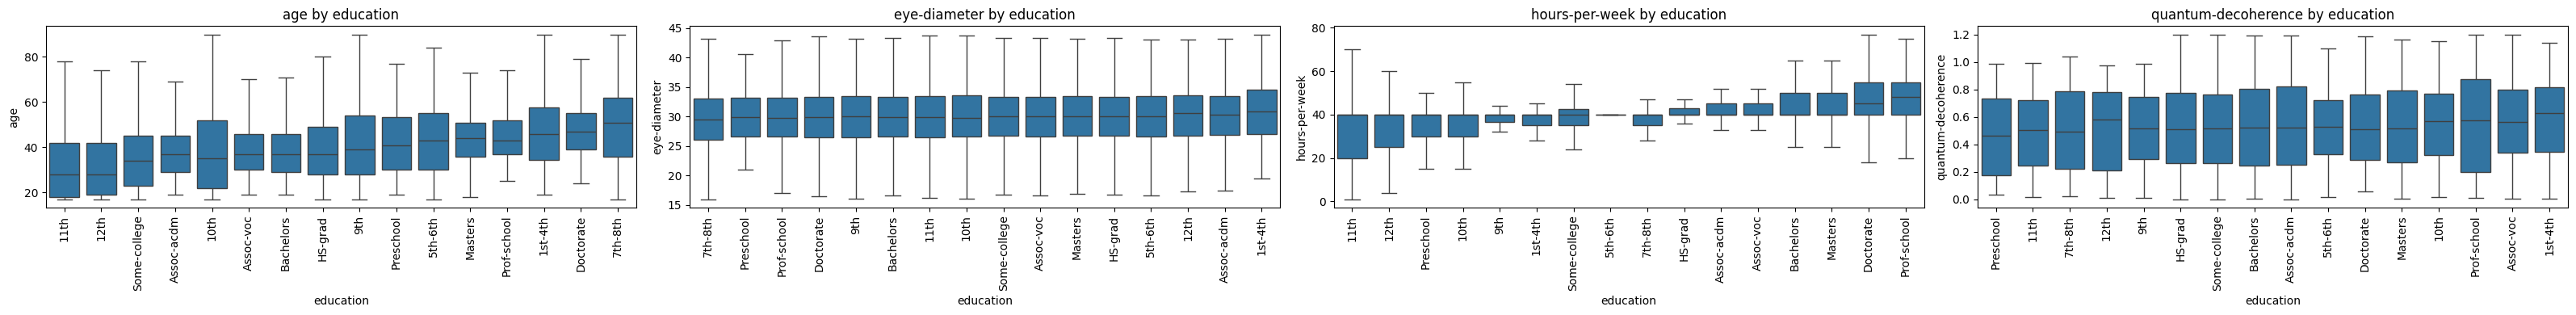

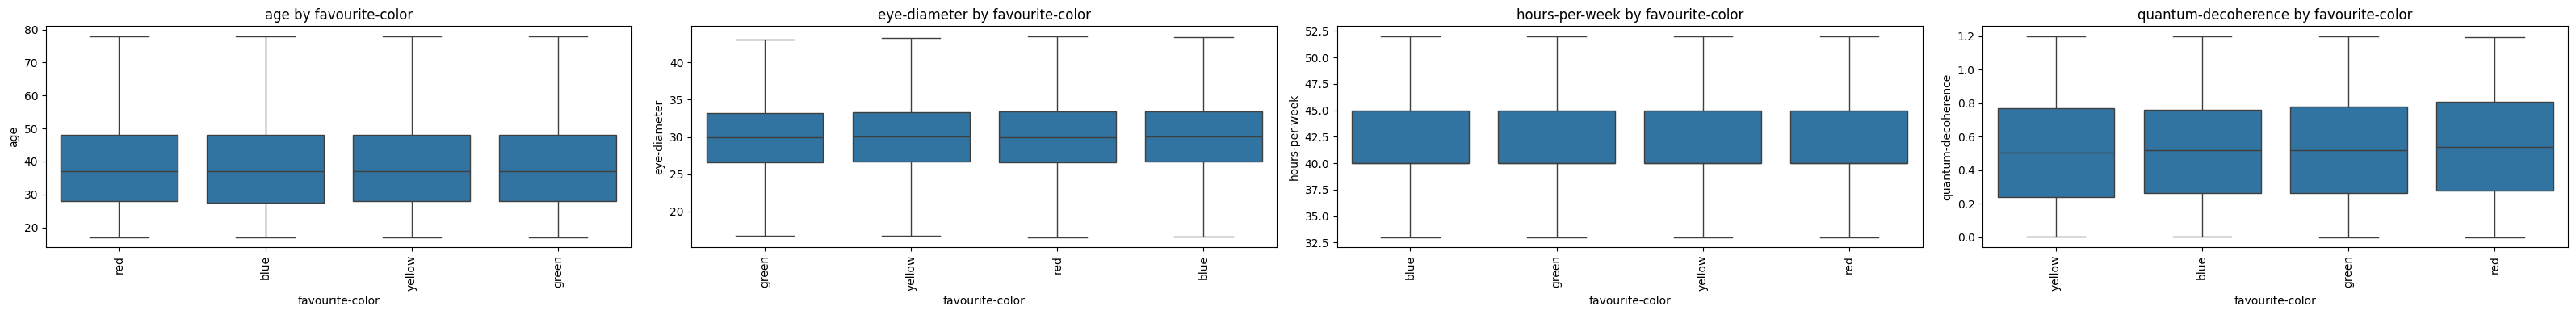

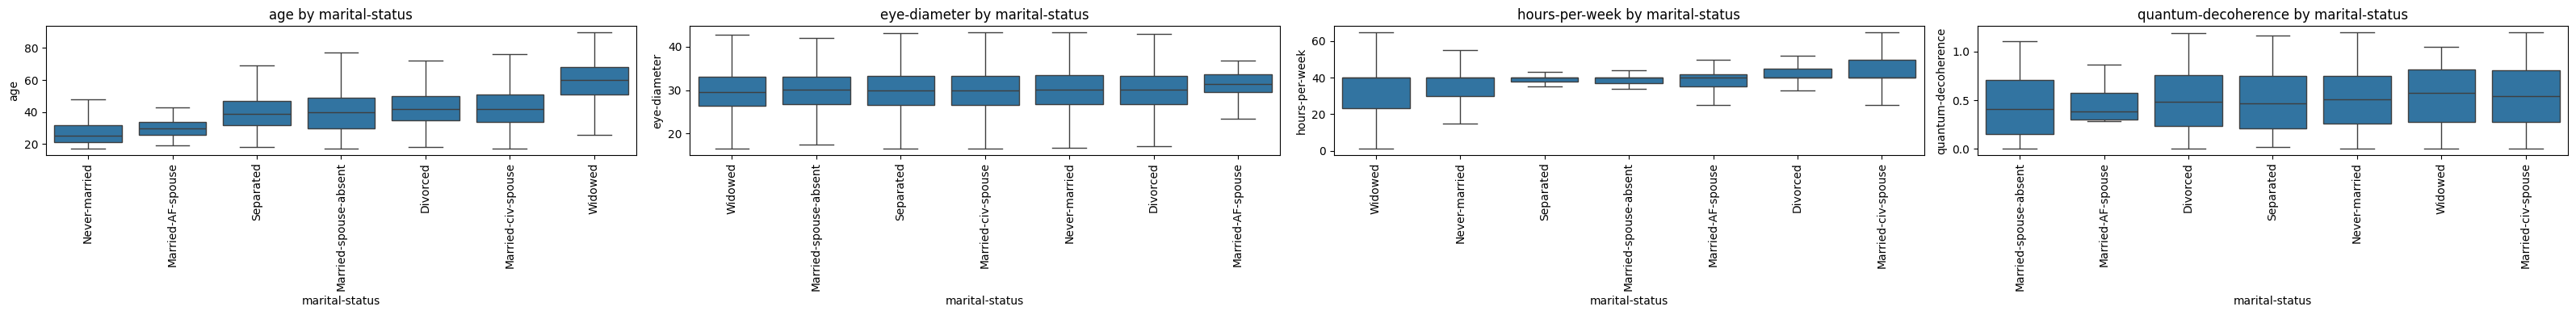

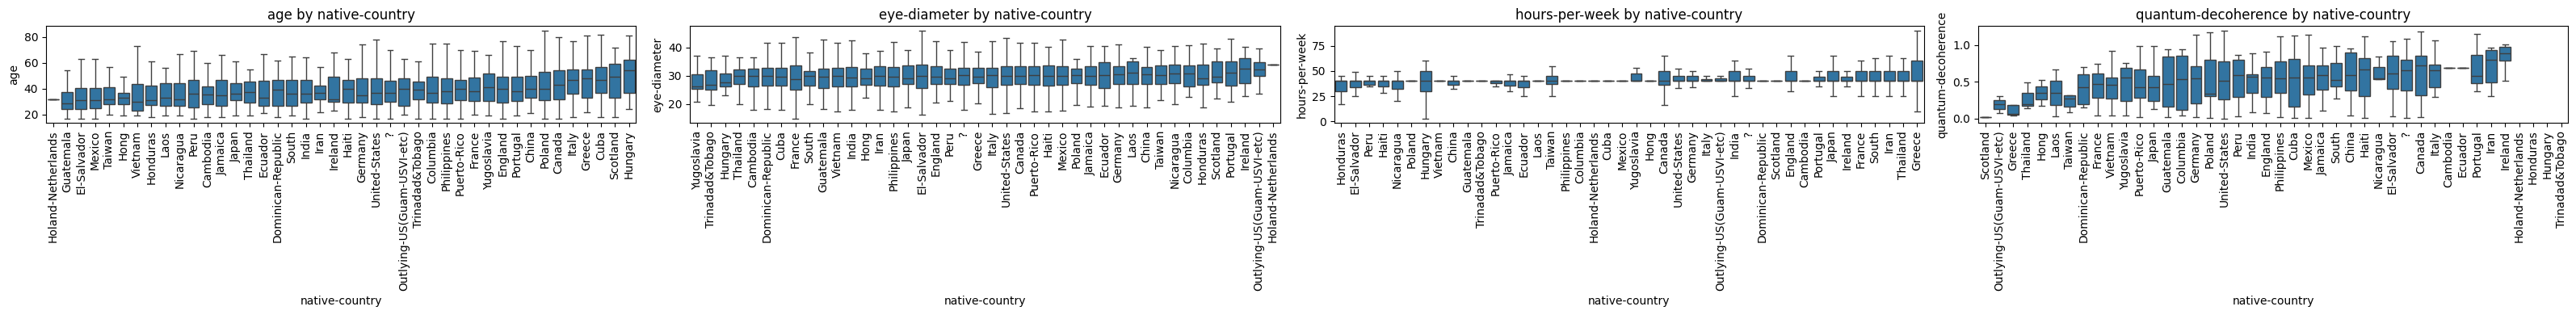

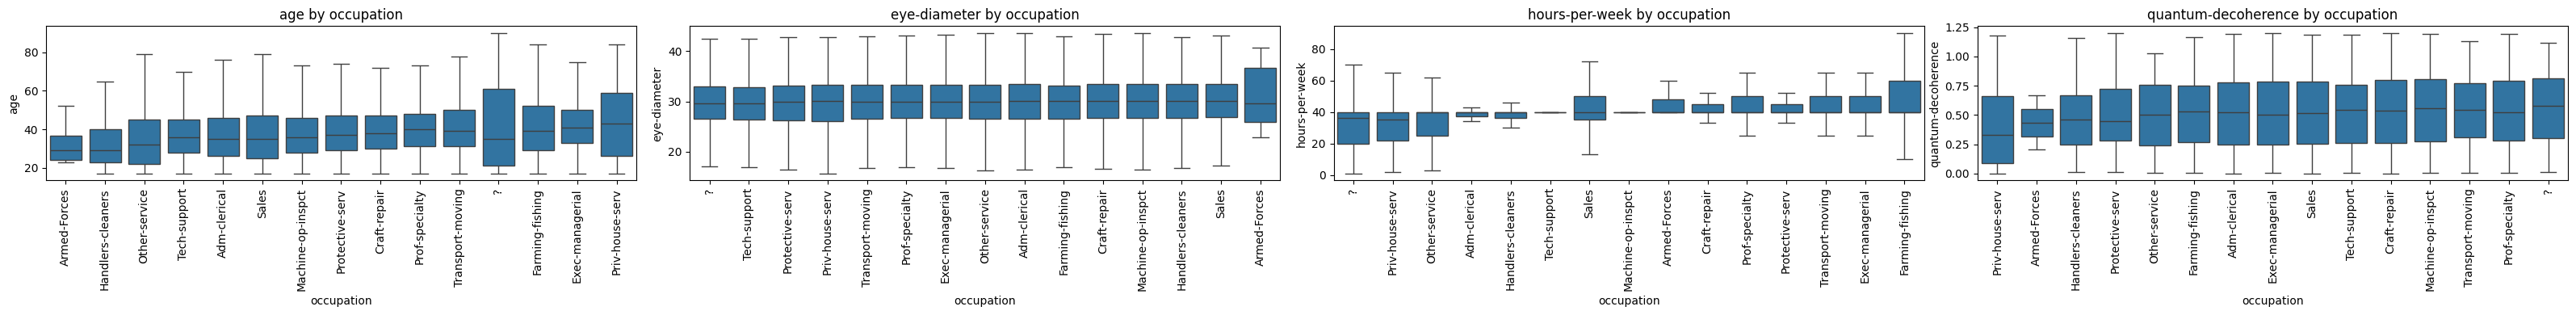

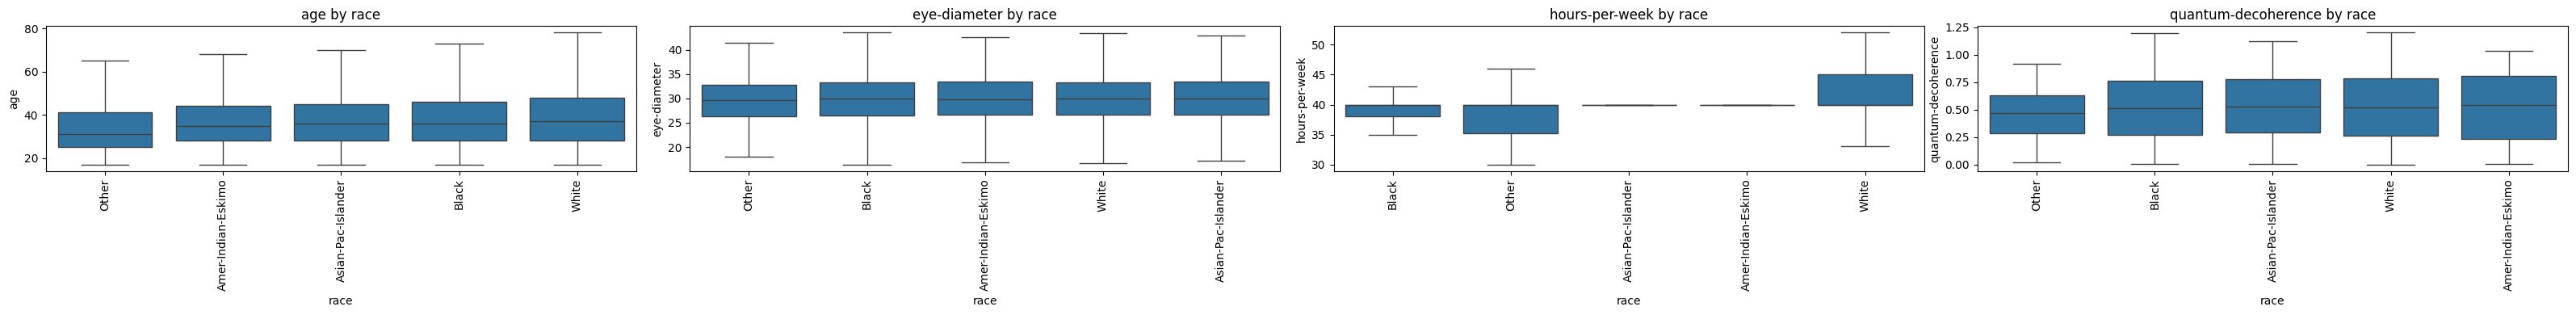

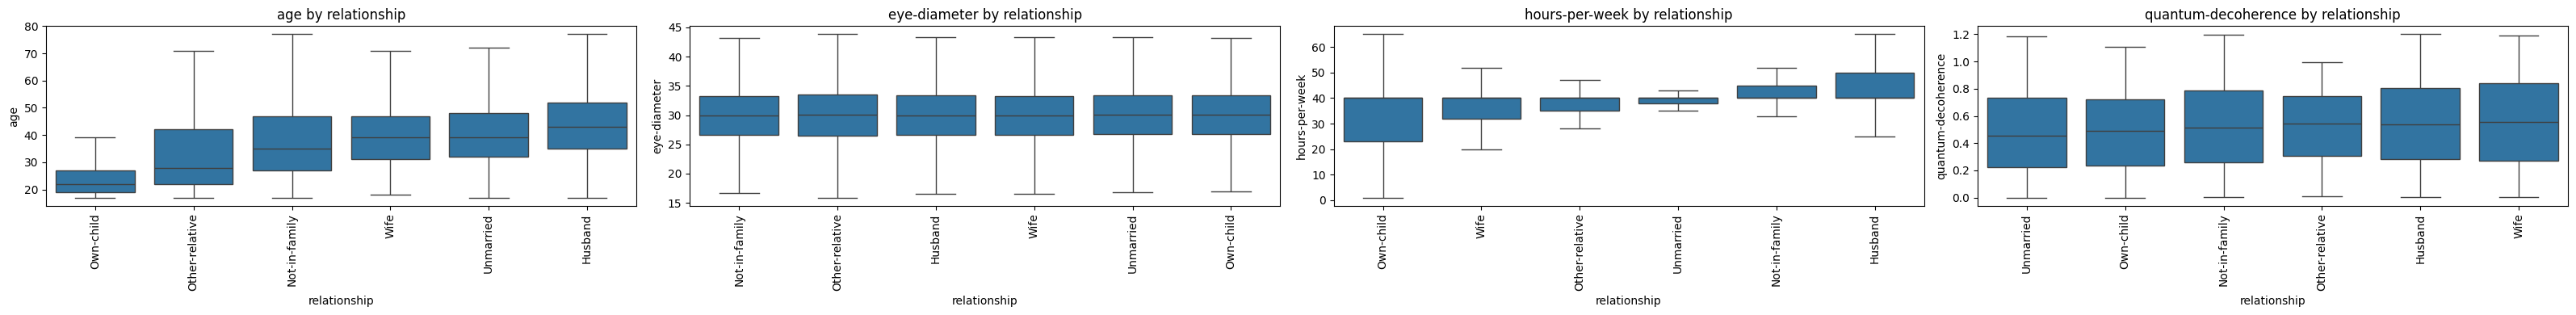

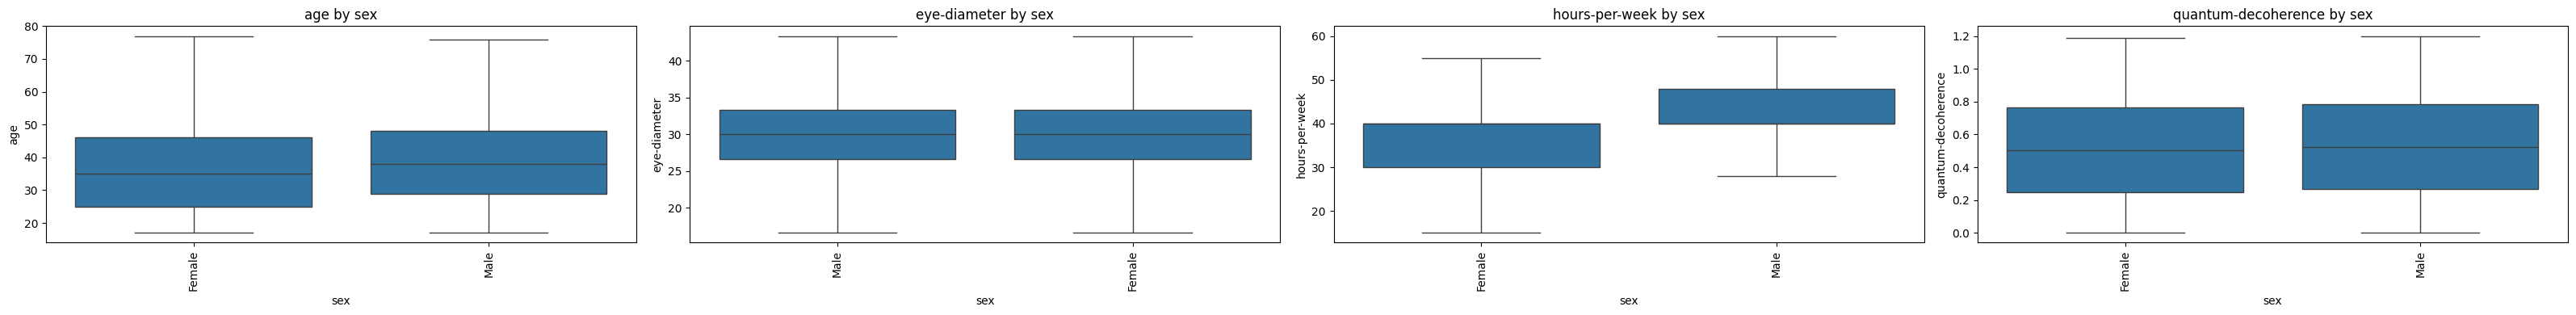

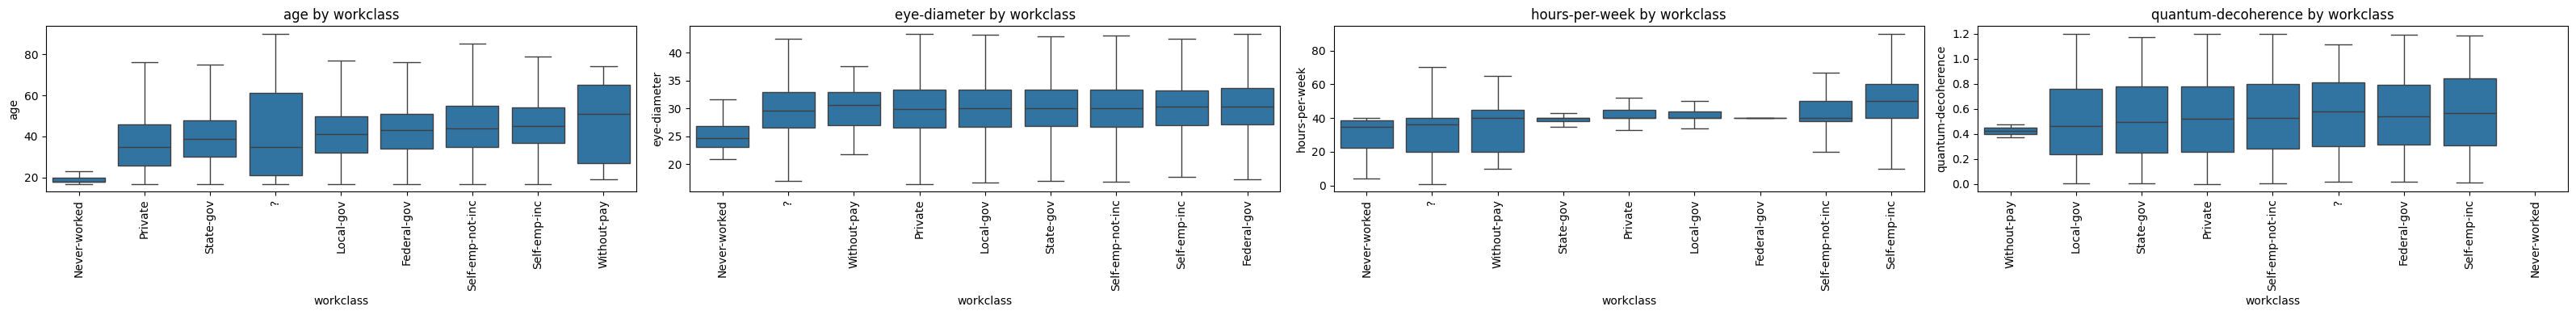

In [22]:
# per ogni feature categorica, plottiamo la distribuzione delle feature continue 
# per vedere se ci sono pattern o differenze nelle distribuzioni

# per ogni feature categorica, creiamo un subplot con le feature numeriche selezionate come boxplot
selected_numerical_features = [f for f in numerical_features if f not in ['capital-gain', 'capital-loss']]
for cat_feature in X.columns:
    if is_categorical[cat_feature]:
        n_num = len(selected_numerical_features)
        fig, axes = plt.subplots(1, n_num, figsize=(8 * n_num, 4), sharey=False)
        for idx, num_feature in enumerate(selected_numerical_features):
            # Compute mean of the numerical feature for each category
            means = X.groupby(cat_feature)[num_feature].mean().sort_values()
            order = means.index.tolist()
            sns.boxplot(
                x=X[cat_feature],
                y=X[num_feature],
                ax=axes[idx],
                showfliers=False,  # ignore outliers
                order=order
            )
            axes[idx].set_title(f'{num_feature} by {cat_feature}')
            axes[idx].tick_params(axis='x', rotation=90)
        plt.tight_layout()
        plt.show()

<span style="color:red"><strong>Risposta</strong></span>:
```
...
```

<span style="color:red"><strong>TODO 9</strong></span>: di seguito vediamo la proporzione del target positivo tra elementi che appartengono alla stessa classe categorica. Cosa ci dice?

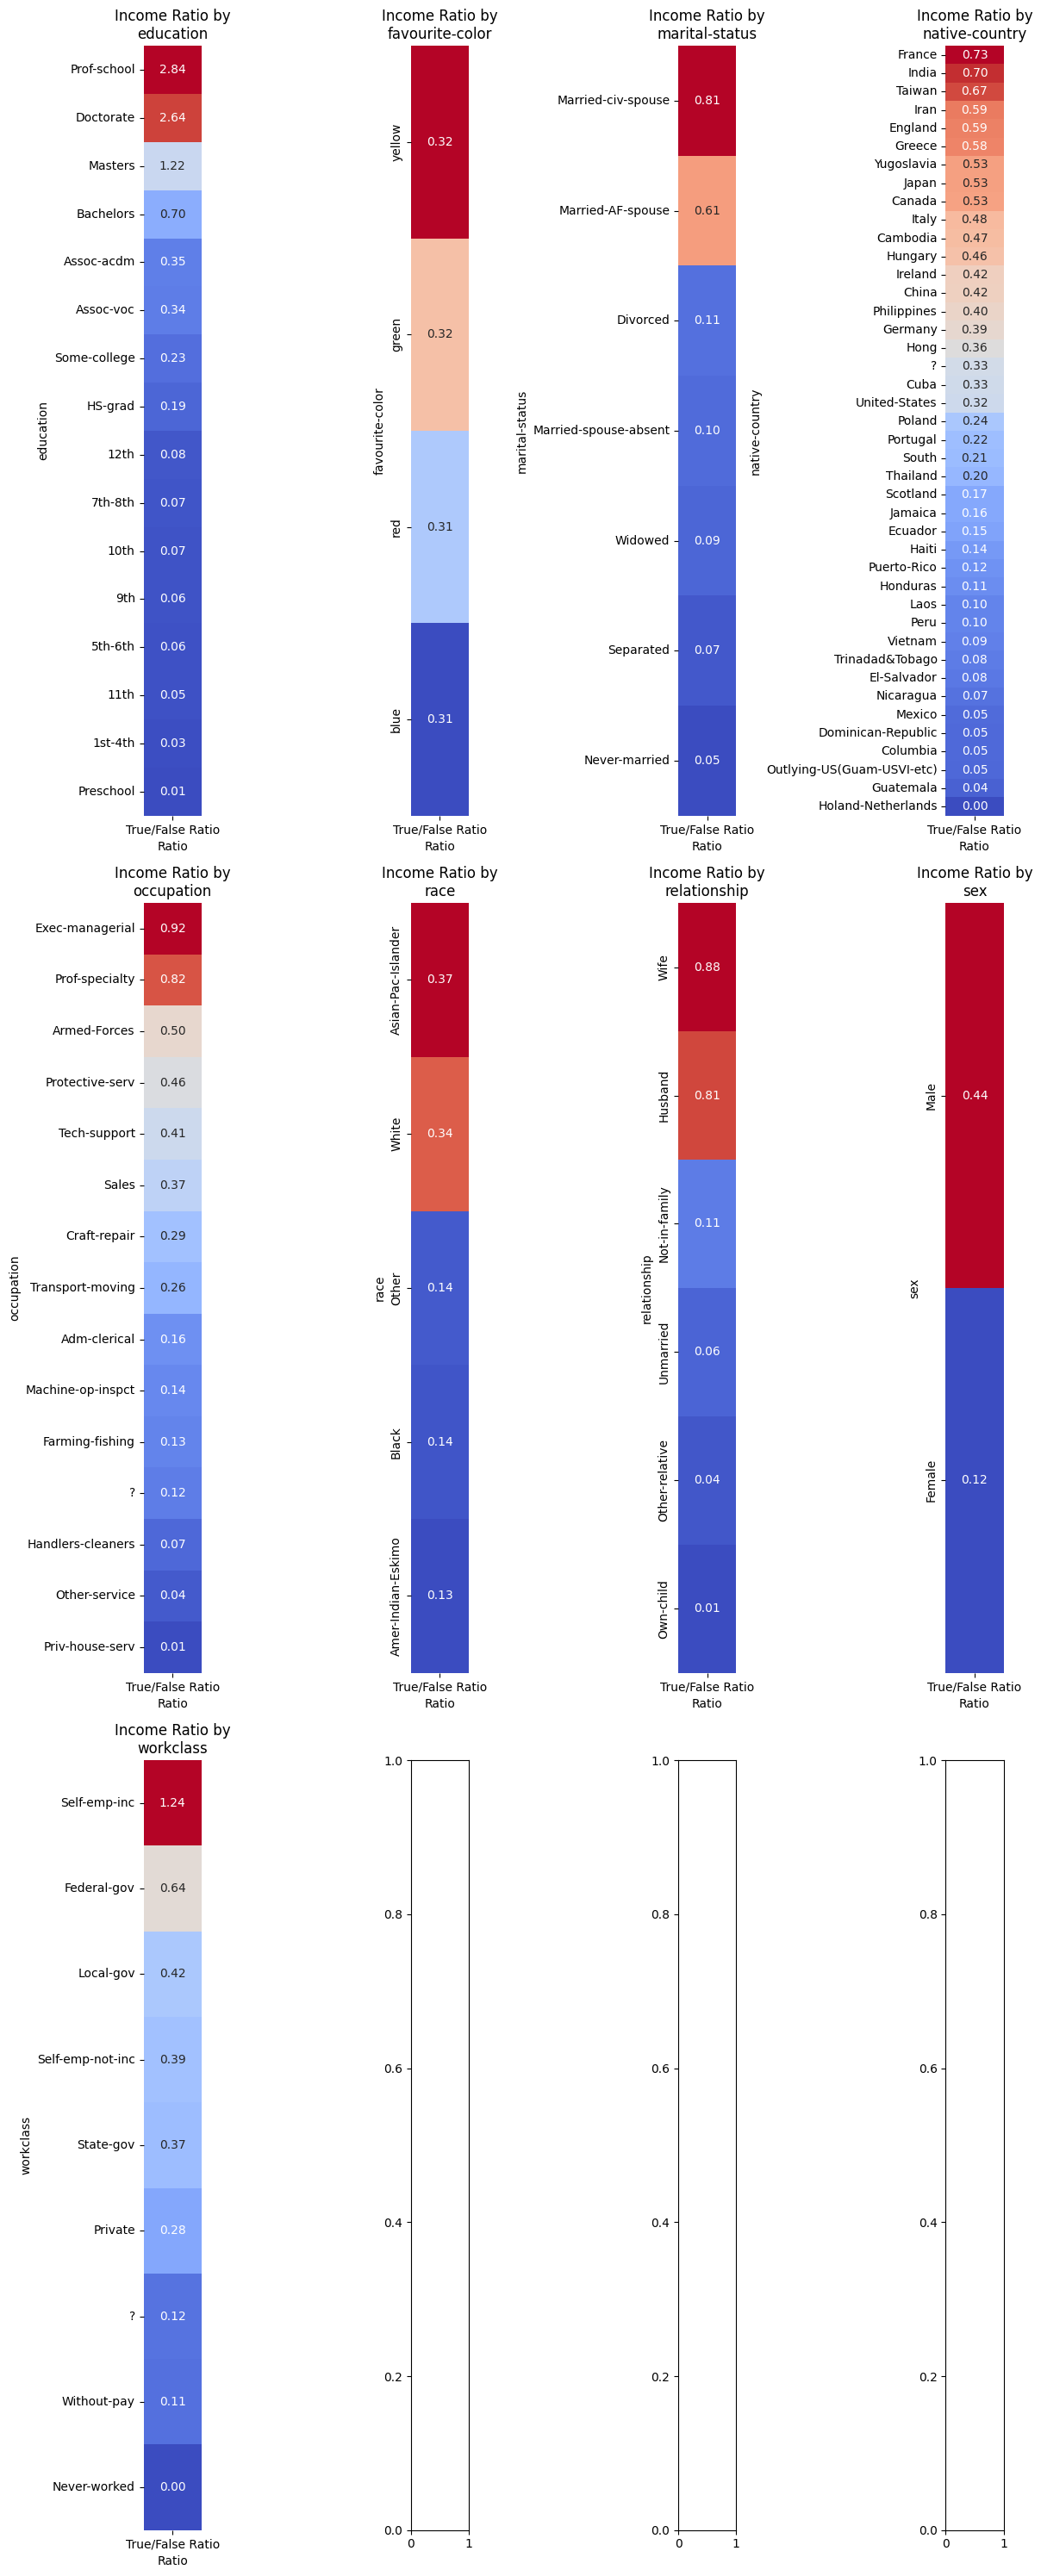

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_features = [f for f in X.columns if is_categorical[f]]
n_cat = len(cat_features)

n_cols = 4
n_rows = (n_cat + n_cols - 1) // n_cols  
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 10 * n_rows))
axes = axes.flatten()

for i, cat_feature in enumerate(cat_features):
    # calcola il rapporto True/False per ogni categoria
    ct = pd.crosstab(df[cat_feature], df[target_col])
    ratio = ct[True] / ct[False]
    ratio_df = ratio.to_frame(name="True/False Ratio").sort_values(by="True/False Ratio", ascending=False)
    sns.heatmap(
        ratio_df, cmap="coolwarm", annot=True, fmt=".2f", ax=axes[i], cbar=False
    )
    axes[i].set_title(f"Income Ratio by\n{cat_feature}")
    axes[i].set_xlabel("Ratio")
    axes[i].set_ylabel(cat_feature)
plt.tight_layout()
plt.show()

<span style="color:red"><strong>Risposta</strong></span>:
```
...
```

### 1.3 Preprocessing

<span style="color:red"><strong>TODO 10</strong></span>: Considerando le valutazioni ottenute nella fase di esplorazione, effettua un pre-processing adeguato del dataset con l'obiettivo di poterlo usare per allenare un modello di machine learning. 

Le operazioni di preprocessing possono includere:

- gestione delle feature non informative
- gestione dei valori mancanti
- codifica delle variabili categoriche
- gestione delle feature ridondanti
- normalizzazione

Motiva le scelte fatte con commenti.

In [24]:
df_c = df.copy()

In [25]:
# Risposta 10:
...

<span style="color:red"><strong>TODO 11</strong></span>: Dovendo allenare e valutare la capacità di generalizzazione di un modello di logistic regression, quale/i altra/e operazioni devi fare sul dataset, prima del training?

Implementa le operazioni da fare, nell'ordine corretto e motiva le tue scelte con commenti.

In [26]:
from exam_utils import random_train_test_split, stratified_train_test_split

# Risposta 11:
...

Ellipsis

## 2. Modelizzazione e algoritmi fondamentali

In un reattore chimico, per ogni lotto si conoscono: 
- `temperatura` di reazione (°C)
- `tempo` di reazione (minuti)

L'obiettivo è costruire un modello di regressesione che, a partire dai valori di temperatura e tempo di reazione, faccia la predizione della resa del prodotto, cioè la `concentrazione` finale del prodotto (%).

Viene fornito un dataset storico con valori di temperatura e tempo di reazioni e le corrispondenti misurazioni reali di concentrazione. Sul dataset è già effettuato il pre-processing necessario. 

In [27]:
data = pd.read_csv("chemical_reaction_data_exam.csv")
data = data.sample(n=900, random_state=n_matricola).reset_index(drop=True) 

# mostriamo le prime righe del dataset
display(data.head())        

,temperatura,tempo,concentrazione
0,32.715923,23.355512,43.982019
1,49.155693,35.612475,73.052034
2,26.330517,24.691696,38.776587
3,48.078821,36.804346,73.869210
4,68.542900,32.275001,59.583201


### Regressione Lineare - Ordinary Least Squares e Ridge Regression

Un punto di partenza ragionevole è ipotizzare che la relazione tra le feature e il target sia linare. Per prima cosa, si potrebbe costruire un modello di **regressione lineare multivariata**: 

$$
f(x) = \beta_0 + \beta_1 x_1 + \beta_2 x_2
$$

<span style="color:red"><strong>TODO 12</strong></span>: costruisci e allena un modello di regressione lineare multivariata usando Ordinary Least Squares. Valuta <u>correttamente</u> le performance di allenamento e generalizzazione del modello appropriate metriche. Commenta i risultati e le tue scelte. 

<span style="color:red"><strong>TODO 12.1 (opzionale)</strong></span>: Costrusci e allena un modello Ridge Regression. Valuta le performance di addestramento e generalizzazione anche di questo modello e confrontale con il modello di OLS. Commenta i risultati. 

<span style="color:red"><strong>NOTA</strong></span>: Il punto 12.1 è opzionale. Puoi comunque ottenere il voto massimo anche senza implementarlo. Tuttavia, completarlo può aiutarti a recuperare eventuali punti persi in altre parti dell'esercizio.

In [28]:
# Risposta 12:
...


# Risposta 12.1 (opzionale):
...


## Piecewise Linear Regression

Un unico modello lineare presenta performance migliorabili sul dataset. Una ricerca più approfondita rivela che il reattore **ha operato in 3 punti di lavoro diversi**.
È noto che **all'interno di ciascun punto di lavoro**, la relazione tra feature e target è **lineare**, tuttavia i **coefficienti sono diversi tra punti di lavoro diversi**. 

Proponi quindi un modello che catturi questi natura a tratti della relazione. Il modello, idealmente, avrà la forma: 
$$
g(x) = 
\begin{cases}
    f_0(x) & \text{se } x \text{ nel regime 0 } (k(x)=0) \\
    f_1(x) & \text{se } x \text{ nel regime 1 } (k(x)=1)\\
    f_2(x) & \text{se } x \text{ nel regime 2 } (k(x)=2)
\end{cases}
$$
dove: 
- $x$ è il vettore delle feature di un sample; 
- $f_i(x) = \beta_{0,i} + \beta_{1,i} x_1 + \beta_{2,i} x_2$ è il modello valido per il punto di lavoro $i$; 

<span style="color:red"><strong>NOTA IMPORTANTE</strong></span>: Il punto di lavoro a cui $x$ appartiente non ha una label esplicita, ma può essere **inferito dal dataset tramite clustering**.

<span style="color:red"><strong>TODO 13</strong></span>: 

- <span style="color:red"><strong>TODO 13.1</strong></span>: Implementa e usa **k-means** per raggruppare l'intero dataset X nei vari punti di lavoro. 
- <span style="color:red"><strong>TODO 13.2</strong></span>: Per ciascun punto di lavoro, costruisci un modello locale $f_i(x)$ valido sui dati provenienti da il corrispondente punto di lavoro. 
- <span style="color:red"><strong>TODO 13.3</strong></span>: **Combina** i modelli: costruisci il modello finale $g(x)$ che seleziona dinamicamente quale funzione $f_i(x)$ usare, in base al punto di lavoro a cui appartiene $x$.
- <span style="color:red"><strong>TODO 13.4</strong></span>: **Valutazione**: usando la tecnica più appropriata, confronta le performance del modello unico OLS del punto precedente $f(x)$ e del modello combinato $g(x)$. 

In [29]:
# K-means è sensibile all'iniziallizzazione dei centroidi. 
# Se vuoi, setta qui un seed per la riproducibilità. Se l'inizializzazione dei tuoi centroidi con questo seed non è buona, puoi cambiare il seed. 

# np.random.seed(1)

In [30]:
# Risposta 13.1:

...

Ellipsis

In [31]:
# Risposta 13.2:

...

Ellipsis

In [32]:
# Risposta 13.3:

...

Ellipsis

In [33]:
# Risposta 13.4:

...

Ellipsis

## 3. Nuovo algoritmo: Versione più leggera di k-means

Nei passaggi precedenti, avete visto casi in cui è conveniente dividere il dataset in cluster e allenare classificatori separati per ciascun cluster. Per classificare un nuovo punto, è necessario associare il punto al cluster più vicino e poi utilizzare il classificatore corrispondente. A questo punto, il centroide del cluster associato dovrebbe essere aggiornato.

Tuttavia, l’aggiornamento dei cluster richiede tipicamente di memorizzare tutti i punti del dataset in memoria, il che aumenta significativamente l’uso della memoria rispetto all’allenamento di un singolo modello per l’intero dataset.

Per ovviare a questo, possiamo considerare versioni più leggere di k-means che non richiedono di conservare l’intero dataset in memoria.

### Batched k-means

Invece di memorizzare *tutti i punti* in memoria per aggiornare i centroidi, considera di mantenere solo un *sottoinsieme a dimensione fissa* dei dati.

In particolare:

- Definisci il budget di memoria come $M = m \times k$, dove: 




  - $m$ è un parametro regolabile (ad esempio, $m = 10$)  
  - $k$ è il numero di cluster  




- Implementa una variante di k-means in cui solo $M$ punti vengono salvati in memoria.

- Quando un nuovo punto viene assegnato a un cluster:  
  - Campiona nuovamente $M$ punti da mettere nel buffer, tra gli $M$ punti esistenti + quello nuovo.
  - Aggiorna il centroide utilizzando *solo i punti memorizzati nel buffer*.

<span style="color:red"><strong>TODO 14</strong></span>:

- <span style="color:red"><strong>TODO 14.1</strong></span>: Progetta questa versione leggera di k-means, facendo attenzione alla *strategia di campionamento* per selezionare quali punti salvare in memoria.

- <span style="color:red"><strong>TODO 14.2</strong></span>: Allena poi questa versione di k-means sullo stesso dataset dell'esercizio precedente.

- <span style="color:red"><strong>TODO 14.3 (opzionale)</strong></span>: Visualizza i cluster e uno scatter plot del dataset.

<span style="color:red"><strong>NOTE (opzionale)</strong></span>: il punto 14.3 è opzionale, puoi prendere il massimo dei voti anche senza implementarlo, ma può darti qualche punto in più e può aiutarti a capire come sta funzionando il tuo algoritmo.


In [34]:
# Risposta 14.1:
...

In [35]:
# Risposta 14.2:
...

In [36]:
# Risposta 14.3: (Visualizzazione opzionale)
...

## Online k-means

E se potessi memorizzare solo $k$ valori in memoria, nello specifico, gli $k$ centroidi? Quando arriva un nuovo punto e viene assegnato a un cluster, puoi aggiornare il centroide senza avere a disposizione i punti di quel cluster?

<span style="color:red"><strong>TODO 15</strong></span>:
- <span style="color:red"><strong>TODO 15.1</strong></span>: Implementa una versione modificata di k-means dove nessun punto del dataset viene salvato in memoria, ma viene salvata solo la posizione attuale dei centroidi.
- <span style="color:red"><strong>TODO 15.2</strong></span>: Allena questa versione di k-means sullo stesso dataset dell'esercizio precedente.
- <span style="color:red"><strong>TODO 15.3 (opzionale)</strong></span>: visualizza i cluster e uno scatter plot del dataset.

<span style="color:red"><strong>NOTE</strong></span>: il punto 15.3 è opzionale, puoi prendere il massimo dei voti anche senza implementarlo, ma può darti qualche punto in più e può aiutarti a capire come sta funzionando il tuo algoritmo.

**Suggerimento:** Tieni traccia del numero di punti assegnati a ciascun cluster come variabile separata.

In [37]:
# Risposta 15.1:
...

In [38]:
# Risposta 15.2:
...

In [39]:
# Risposta 15.3:
...